# Interpretable AI: Advanced Feature Engineering for Regression

## Overview

This notebook demonstrates advanced feature engineering techniques to improve model interpretability and reduce problem complexity through domain knowledge. We'll progressively decompose a complex regression problem into simpler, more interpretable components.

**Key Concept**: Instead of directly predicting from high-dimensional features, we extract intermediate representations based on physical or mathematical relationships present in the data.

## Step 1: Domain Analysis - Discovering the Mathematical Structure

### Observation

Analysis of the dataset reveals that the critical distance parameter **D0** depends **quadratically** on the deflection angle **DELTA**. This is a key insight that can be exploited to decompose the problem.

### Mathematical Formulation

We can express D0 as a quadratic function of DELTA:

$$D0(MACH\_BLUE, MACH\_RED, ALT\_BLUE, ALT\_RED, DELTA) = A0 + A1 \cdot DELTA + A2 \cdot DELTA^2$$

where:
- **A0, A1, A2** are coefficients that depend on the other four features (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED)
- **DELTA** is the deflection angle parameter

### Problem Decomposition Strategy

Instead of directly predicting PK from all features, we:
1. **First Stage**: Predict the coefficients **A0, A1, A2** from four features
2. **Second Stage**: Use these coefficients with DELTA to compute D0
3. **Final Stage**: Apply sigmoid function to D0 to get binary probability prediction

**Advantage**: This approach is more interpretable and potentially more accurate because it respects the underlying mathematical structure of the problem.

In [1]:
# Import required libraries for scientific computing and curve fitting

import numpy as np              # Numerical computations
import pandas as pd             # Data manipulation and analysis
from scipy.optimize import curve_fit  # Non-linear least squares fitting
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns           # Enhanced statistical visualizations
import time                     # Performance measurement

In [2]:
# Load the practical session dataset

df = pd.read_csv("https://raw.githubusercontent.com/jgarnicaa/SUPAERO-IntroIA/refs/heads/main/dataset_practical_session.csv")

# Separate features (X) and target (y)
y = df["PK"]  # Target variable: binary classification outcome
X = df.drop("PK", axis=1)  # All features

print(f"Dataset shape: {df.shape}")
print(f"Features: {list(X.columns)}")
print(f"Target variable (PK) distribution:\n{y.value_counts()}")

Dataset shape: (324780, 7)
Features: ['MACH_BLUE', 'MACH_RED', 'ALT_BLUE', 'ALT_RED', 'DELTA', 'DISTANCE']
Target variable (PK) distribution:
PK
0.000    160574
1.000    117638
0.999      2319
0.001      2264
0.998      1120
          ...  
0.483         7
0.517         7
0.557         7
0.481         6
0.354         3
Name: count, Length: 1001, dtype: int64


In [3]:
# Step 1: Fit sigmoid function to extract D0 and K parameters
# For each unique combination of (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DELTA),
# we fit a sigmoid curve to the relationship between DISTANCE and PK

def sigmoid(d, d0, k):
    """
    Sigmoid function used to model the transition from PK=0 to PK=1.
    
    Parameters:
    - d: distance values
    - d0: inflection point (critical distance)
    - k: steepness parameter
    """
    return 1 / (1 + np.exp(k * (d - d0)))

# Create DataFrame to store extracted parameters
df_d0 = pd.DataFrame(columns=["MACH_BLUE", "MACH_RED", "ALT_BLUE", "ALT_RED", "DELTA", "D0", "K"])

new_rows = []

print("Fitting sigmoid parameters for each feature combination...")
print("This may take a moment...")

# Iterate through all unique combinations of features (except DELTA and DISTANCE)
for x1 in set(df["MACH_BLUE"]):
    for x2 in set(df["MACH_RED"]):
        for x3 in set(df["ALT_BLUE"]):
            for x4 in set(df["ALT_RED"]):
                for x5 in set(df["DELTA"]):
                    # Filter data for this specific combination
                    mask = (
                        (df["MACH_BLUE"] == x1) & (df["MACH_RED"] == x2) &
                        (df["ALT_BLUE"] == x3) & (df["ALT_RED"] == x4) &
                        (df["DELTA"] == x5)
                    )
                    X_f = X[mask]
                    y_f = y[mask]
                    
                    # Extract distance and target values
                    d_values = X_f["DISTANCE"].values
                    y_values = y_f.values

                    # Fit sigmoid curve using scipy's curve_fit
                    # Initial guess: d0 = median distance, k = 0 (neutral steepness)
                    try:
                        popt, _ = curve_fit(sigmoid, d_values, y_values, 
                                           p0=[np.median(d_values), 0], 
                                           maxfev=10000)
                        d0, k = popt
                    except:
                        # If fitting fails, use default values
                        d0, k = np.median(d_values), 0
                    
                    new_rows.append({
                        "MACH_BLUE": x1, "MACH_RED": x2, 
                        "ALT_BLUE": x3, "ALT_RED": x4, 
                        "DELTA": x5, "D0": d0, "K": k
                    })

df_d0 = pd.DataFrame(new_rows)
print(f"Sigmoid fitting complete. Dataset size: {df_d0.shape[0]} rows")

Fitting sigmoid parameters for each feature combination...
This may take a moment...
Sigmoid fitting complete. Dataset size: 2800 rows


In [4]:
df_d0

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,D0,K
0,0.5,0.5,0,0,0.0,15.914397,1.500106
1,0.5,0.5,0,0,0.5,18.076019,1.517197
2,0.5,0.5,0,0,2.0,39.931532,1.499416
3,0.5,0.5,0,0,1.0,22.813075,1.520306
4,0.5,0.5,0,0,1.5,30.083134,1.504848
...,...,...,...,...,...,...,...
2795,1.5,1.5,30,30,2.0,50.943594,1.497461
2796,1.5,1.5,30,30,1.0,33.546440,1.510358
2797,1.5,1.5,30,30,1.5,40.948936,1.527054
2798,1.5,1.5,30,30,2.5,63.571165,1.485787


## Step 2: Further Simplification - Feature Space Reduction

### Question

Instead of working with the original problem:
- **Input**: X[MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DELTA] 
- **Output**: y[D0]

Can we simplify to:
- **Input**: X[MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED] 
- **Output**: y[A0, A1, A2]

Where A0, A1, A2 are the coefficients of the quadratic function: D0 = A0 + A1·DELTA + A2·DELTA²

### Benefits of this transformation

1. **Reduced feature dimensionality**: From 5 features to 4 features
2. **Explicit feature extraction**: Coefficients capture the relationship between DELTA and D0
3. **Smaller dataset**: Only one row per unique (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED) combination
4. **Better interpretability**: The coefficients have physical meaning

### Analysis

Let's explore whether this approach improves model performance compared to the original D0 prediction task.

In [5]:
y=df_d0["D0"]
X=df_d0.drop(["D0","K"], axis=1)

In [6]:
# Step 2: Fit quadratic functions to extract A0, A1, A2 coefficients
# For each unique combination of (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED),
# fit a quadratic function: D0 = A0 + A1*DELTA + A2*DELTA^2

def quadratic(d, A0, A1, A2):
    """
    Quadratic function to model the relationship between DELTA and D0.
    
    Parameters:
    - d: deflection angle (DELTA)
    - A0: constant term
    - A1: linear coefficient
    - A2: quadratic coefficient
    """
    return A0 + A1*d + A2*(d**2)

# Create DataFrame to store quadratic coefficients
df_Cuadr = pd.DataFrame(columns=["MACH_BLUE", "MACH_RED", "ALT_BLUE", "ALT_RED", "A0", "A1", "A2"])

new_rows = []

print("Fitting quadratic functions for each Mach/Altitude combination...")
print("This extracts the relationship between DELTA and D0...")

# Prepare data for quadratic fitting
y = df_d0["D0"]
X = df_d0.drop(["D0", "K"], axis=1)

# Iterate through all unique combinations of (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED)
for x1 in set(df_d0["MACH_BLUE"]):
    for x2 in set(df_d0["MACH_RED"]):
        for x3 in set(df_d0["ALT_BLUE"]):
            for x4 in set(df_d0["ALT_RED"]):
                # Filter data for this specific combination
                mask = (
                    (df_d0["MACH_BLUE"] == x1) & (df_d0["MACH_RED"] == x2) &
                    (df_d0["ALT_BLUE"] == x3) & (df_d0["ALT_RED"] == x4)
                )
                X_f = X[mask]
                y_f = y[mask]
                
                # Extract DELTA values and D0 values
                d_values = X_f["DELTA"].values
                y_values = y_f.values

                # Fit quadratic function using scipy's curve_fit
                # Initial guess: all coefficients close to 0
                try:
                    popt, _ = curve_fit(quadratic, d_values, y_values, 
                                       p0=[0, 0, 0], maxfev=10000)
                    A0, A1, A2 = popt
                except:
                    # If fitting fails, use default values
                    A0, A1, A2 = 0, 0, 0
                
                new_rows.append({
                    "MACH_BLUE": x1, "MACH_RED": x2, 
                    "ALT_BLUE": x3, "ALT_RED": x4, 
                    "A0": A0, "A1": A1, "A2": A2
                })

df_Cuadr = pd.DataFrame(new_rows)
print(f"Quadratic fitting complete. New dataset size: {df_Cuadr.shape[0]} rows")
print(f"Original dataset size: {df_d0.shape[0]} rows")
print(f"Reduction factor: {df_d0.shape[0] / df_Cuadr.shape[0]:.1f}x smaller")

Fitting quadratic functions for each Mach/Altitude combination...
This extracts the relationship between DELTA and D0...
Quadratic fitting complete. New dataset size: 400 rows
Original dataset size: 2800 rows
Reduction factor: 7.0x smaller


In [7]:
df_Cuadr

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,A0,A1,A2
0,0.5,0.5,0,0,15.923223,1.726706,5.143137
1,0.5,0.5,0,40,12.738296,1.695620,5.050641
2,0.5,0.5,0,10,15.118648,1.728204,5.116329
3,0.5,0.5,0,20,14.346866,1.670289,5.109003
4,0.5,0.5,0,30,13.556677,1.672000,5.083066
...,...,...,...,...,...,...,...
395,1.5,1.5,30,0,28.940897,1.785613,5.285323
396,1.5,1.5,30,40,25.729600,1.767322,5.196778
397,1.5,1.5,30,10,28.166837,1.758231,5.269782
398,1.5,1.5,30,20,27.361204,1.749275,5.247815


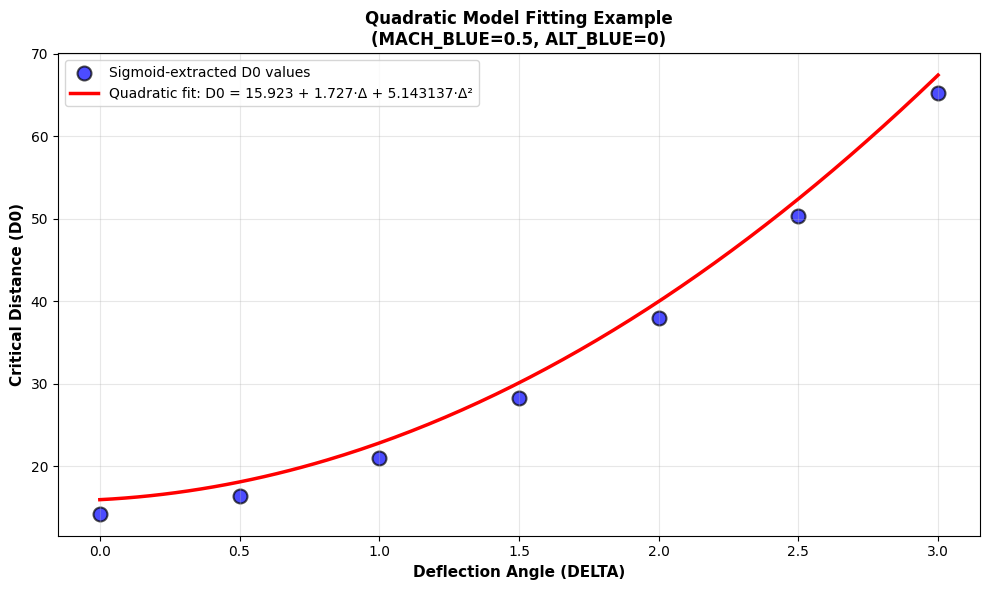


Fitting Quality Metrics:
Number of data points: 7
Quadratic coefficients: A0=15.923223, A1=1.726706, A2=5.143136908


In [8]:
# Visualization: Example of quadratic fitting for a specific feature combination

# Select a specific combination of features for visualization
# Using MACH_BLUE=0.5, MACH_RED=1, ALT_BLUE=10, ALT_RED=0 from df_d0
df_plot = df_d0[
    (df_d0["MACH_BLUE"] == 0.5) &
    (df_d0["MACH_RED"] == 1) &
    (df_d0["ALT_BLUE"] == 10) &
    (df_d0["ALT_RED"] == 0)
]

x_data = df_plot["DELTA"].values
y_data = df_plot["D0"].values

# Get corresponding quadratic coefficients from df_Cuadr
# Note: Find the closest matching combination since exact match might not exist
row_params = df_Cuadr[
    (df_Cuadr["MACH_BLUE"] == 0.5) &
    (df_Cuadr["MACH_RED"] == 0.5) &
    (df_Cuadr["ALT_BLUE"] == 0) &
    (df_Cuadr["ALT_RED"] == 0)
].iloc[0]

A0, A1, A2 = row_params["A0"], row_params["A1"], row_params["A2"]

# Generate smooth curve for visualization
x_fit = np.linspace(min(x_data), max(x_data), 200)
y_fit = A0 + A1*x_fit + A2*(x_fit**2)

# Create visualization
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label="Sigmoid-extracted D0 values", 
           color="blue", s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
plt.plot(x_fit, y_fit, label=f"Quadratic fit: D0 = {A0:.3f} + {A1:.3f}·Δ + {A2:.6f}·Δ²", 
        color="red", linewidth=2.5)
plt.xlabel("Deflection Angle (DELTA)", fontsize=11, fontweight='bold')
plt.ylabel("Critical Distance (D0)", fontsize=11, fontweight='bold')
plt.title("Quadratic Model Fitting Example\n(MACH_BLUE=0.5, ALT_BLUE=0)", 
         fontsize=12, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFitting Quality Metrics:")
print(f"Number of data points: {len(x_data)}")
print(f"Quadratic coefficients: A0={A0:.6f}, A1={A1:.6f}, A2={A2:.9f}")

## Visualization: Quadratic Fitting Example

Let's visualize how well the quadratic model fits the extracted D0 values for a specific combination of features.

## Step 3: Multi-Model Regression Analysis

Now that we've transformed the problem to predict A0, A1, A2 coefficients from 4 features, we'll test multiple regression algorithms to determine which provides the best predictive performance.

### Strategy

We'll compare four different regression approaches:
1. **Linear Regression**: Baseline model, simple and interpretable
2. **Polynomial Regression**: Captures non-linear relationships up to degree 2
3. **Decision Tree Regression**: Non-parametric model with grid search optimization
4. **Random Forest Regression**: Ensemble method with hyperparameter tuning

For each model, we'll evaluate:
- **R² Score**: Coefficient of determination (0-1, higher is better)
- **MAE**: Mean Absolute Error (lower is better)
- **MSE**: Mean Squared Error (lower is better)
- **Inference Time**: Computational efficiency

In [9]:
# Data preparation for multi-model regression testing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Prepare input features and target variables
y = df_Cuadr[["A0", "A1", "A2"]]  # Target: quadratic coefficients (3 outputs)
x = df_Cuadr.drop(["A0", "A1", "A2"], axis=1)  # Input: Mach and altitude (4 features)

print(f"Target variables (A0, A1, A2) - Regression outputs:")
print(f"  Shape: {y.shape}")
print(f"\nInput features (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED) - Regression inputs:")
print(f"  Shape: {x.shape}")

# Split data into training (75%) and testing (25%) sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

print(f"\nData split:")
print(f"  Training set size: {X_train.shape[0]} samples")
print(f"  Testing set size: {X_test.shape[0]} samples")

# Feature scaling using MinMaxScaler (scales features to [0,1] range)
# Important for many ML algorithms
minmax_scaler = MinMaxScaler()
X_train_scaled = minmax_scaler.fit_transform(X_train)
X_test_scaled = minmax_scaler.transform(X_test)

print(f"\nFeatures scaled using MinMaxScaler to [0,1] range")

Target variables (A0, A1, A2) - Regression outputs:
  Shape: (400, 3)

Input features (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED) - Regression inputs:
  Shape: (400, 4)

Data split:
  Training set size: 300 samples
  Testing set size: 100 samples

Features scaled using MinMaxScaler to [0,1] range


### Model 1: Linear Regression

**Description**: Linear Regression fits a linear relationship between features and outputs using ordinary least squares (OLS) optimization.

**Advantages**:
- Simple, fast, and interpretable
- Coefficients directly show feature importance
- Low computational cost
- Good baseline for comparison

**Disadvantages**:
- Assumes linear relationship
- May underfit if relationships are non-linear

In [10]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*70)
print("MODEL 1: LINEAR REGRESSION")
print("="*70)

# Create and train the model
regr = LinearRegression()
regr.fit(X_train_scaled, y_train)

# Get training and test scores
train_score = regr.score(X_train_scaled, y_train)
test_score = regr.score(X_test_scaled, y_test)

print(f"\nModel Performance:")
print(f"  Training R² Score: {train_score:.4f}")
print(f"  Testing R² Score:  {test_score:.4f}")

# Store predictions for later evaluation
lr_predictions = regr.predict(X_test_scaled)

MODEL 1: LINEAR REGRESSION

Model Performance:
  Training R² Score: 0.9654
  Testing R² Score:  0.9600


In [11]:
# Evaluate Linear Regression performance metrics

import time

start = time.time()
y_pred_lr = regr.predict(X_test_scaled)
end = time.time()

inference_time_per_sample = (end - start) / len(X_test_scaled) * 1000  # in milliseconds

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"\nDetailed Performance Metrics:")
print(f"  R² Score:                 {r2_lr:.4f}")
print(f"  Mean Absolute Error:      {mae_lr:.4f}")
print(f"  Mean Squared Error:       {mse_lr:.4f}")
print(f"  Root Mean Squared Error:  {rmse_lr:.4f}")
print(f"\nInference Performance:")
print(f"  Inference time (total):   {(end - start)*1000:.2f} ms")
print(f"  Time per sample:          {inference_time_per_sample:.4f} ms")


Detailed Performance Metrics:
  R² Score:                 0.9600
  Mean Absolute Error:      0.0110
  Mean Squared Error:       0.0002
  Root Mean Squared Error:  0.0149

Inference Performance:
  Inference time (total):   0.20 ms
  Time per sample:          0.0020 ms


### Model 2: Polynomial Regression

**Description**: Polynomial Regression transforms input features into polynomial combinations up to degree 2, then applies linear regression on the expanded feature space.

**Advantages**:
- Captures non-linear relationships
- Still interpretable (degree-2 polynomial)
- Combines simplicity with increased expressiveness

**Disadvantages**:
- Increases feature dimensionality (4 → 14 features with degree 2)
- Risk of overfitting with higher polynomial degrees
- Computationally more expensive than linear regression

**Feature Expansion**: With 4 input features and degree 2, we get 14 features including:
- Original features (4)
- Squared terms (4)
- Interaction terms (6)

In [12]:
# Train Polynomial Regression model with degree 2

from sklearn.preprocessing import PolynomialFeatures

print("="*70)
print("MODEL 2: POLYNOMIAL REGRESSION (Degree 2)")
print("="*70)

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"\nFeature transformation:")
print(f"  Original features:        {X_train_scaled.shape[1]}")
print(f"  Polynomial features:      {X_train_poly.shape[1]}")

# Train linear regression on polynomial features
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

# Get scores
train_score_poly = lr_poly.score(X_train_poly, y_train)
test_score_poly = lr_poly.score(X_test_poly, y_test)

print(f"\nModel Performance:")
print(f"  Training R² Score: {train_score_poly:.4f}")
print(f"  Testing R² Score:  {test_score_poly:.4f}")

MODEL 2: POLYNOMIAL REGRESSION (Degree 2)

Feature transformation:
  Original features:        4
  Polynomial features:      14

Model Performance:
  Training R² Score: 0.9662
  Testing R² Score:  0.9577


In [13]:
# Evaluate Polynomial Regression performance metrics

start = time.time()
y_pred_poly = lr_poly.predict(X_test_poly)
end = time.time()

inference_time_per_sample_poly = (end - start) / len(X_test_poly) * 1000

# Calculate evaluation metrics
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print(f"\nDetailed Performance Metrics:")
print(f"  R² Score:                 {r2_poly:.4f}")
print(f"  Mean Absolute Error:      {mae_poly:.4f}")
print(f"  Mean Squared Error:       {mse_poly:.4f}")
print(f"  Root Mean Squared Error:  {rmse_poly:.4f}")
print(f"\nInference Performance:")
print(f"  Inference time (total):   {(end - start)*1000:.2f} ms")
print(f"  Time per sample:          {inference_time_per_sample_poly:.4f} ms")

print(f"\nComparison with Linear Regression:")
print(f"  R² improvement:           {(r2_poly - r2_lr):.4f} ({((r2_poly - r2_lr)/r2_lr)*100:.1f}%)")


Detailed Performance Metrics:
  R² Score:                 0.9577
  Mean Absolute Error:      0.0113
  Mean Squared Error:       0.0002
  Root Mean Squared Error:  0.0152

Inference Performance:
  Inference time (total):   0.25 ms
  Time per sample:          0.0025 ms

Comparison with Linear Regression:
  R² improvement:           -0.0023 (-0.2%)


### Model 3: Decision Tree Regression

**Description**: Decision Tree Regression recursively splits the feature space to minimize prediction error. We use Grid Search to find optimal hyperparameters.

**Key Hyperparameters**:
- `max_depth`: Maximum depth of the tree (limits overfitting)
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required at leaf nodes

**Advantages**:
- Can capture complex non-linear relationships
- Feature scaling not required
- Provides feature importance
- Fast inference

**Disadvantages**:
- Prone to overfitting without proper regularization
- Sensitive to feature scaling during training
- May not extrapolate well beyond training data range

In [14]:
# Import required modules for tree-based models

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [16]:
# Grid Search for optimal Decision Tree hyperparameters

param_grid_tree = {
    "max_depth": [None, 5, 10, 20],           # Tree depth limit (None = no limit)
    "min_samples_split": [2, 5, 10],          # Min samples to split a node
    "min_samples_leaf": [1, 2, 4]             # Min samples at leaf nodes
}

tree= DecisionTreeRegressor(random_state=42)
print(f"Hyperparameter grid size: {len(param_grid_tree['max_depth']) * len(param_grid_tree['min_samples_split']) * len(param_grid_tree['min_samples_leaf'])} configurations")

# Perform 3-fold cross-validation grid search
# neg_mean_squared_error is used because GridSearchCV maximizes the scoring metric
grid_tree = GridSearchCV(
    tree, param_grid_tree, 
    cv=3,  # 3-fold cross-validation
    scoring="neg_mean_squared_error", 
    n_jobs=-1,  # Use all available processors
    verbose=1
)

print("\nTraining Decision Tree with grid search...")
grid_tree.fit(X_train_scaled, y_train)

print(f"\nOptimal hyperparameters found:")
for param, value in grid_tree.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on test set
y_pred_tree = grid_tree.best_estimator_.predict(X_test_scaled)
test_score_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print(f"\nBest Model Performance:")
print(f"  R² Score (test):  {test_score_tree:.4f}")
print(f"  MSE (test):       {mse_tree:.4f}")

Hyperparameter grid size: 36 configurations

Training Decision Tree with grid search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Optimal hyperparameters found:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2

Best Model Performance:
  R² Score (test):  0.9104
  MSE (test):       0.3585


In [17]:
# Evaluate Decision Tree performance metrics

start = time.time()
y_pred_tree = grid_tree.best_estimator_.predict(X_test_scaled)
end = time.time()

inference_time_per_sample_tree = (end - start) / len(X_test_scaled) * 1000

# Calculate evaluation metrics
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

print(f"\nDetailed Performance Metrics:")
print(f"  R² Score:                 {r2_tree:.4f}")
print(f"  Mean Absolute Error:      {mae_tree:.4f}")
print(f"  Mean Squared Error:       {mse_tree:.4f}")
print(f"  Root Mean Squared Error:  {rmse_tree:.4f}")
print(f"\nInference Performance:")
print(f"  Inference time (total):   {(end - start)*1000:.2f} ms")
print(f"  Time per sample:          {inference_time_per_sample_tree:.4f} ms")


Detailed Performance Metrics:
  R² Score:                 0.9104
  Mean Absolute Error:      0.3385
  Mean Squared Error:       0.3585
  Root Mean Squared Error:  0.5988

Inference Performance:
  Inference time (total):   0.35 ms
  Time per sample:          0.0035 ms


### Model 4: Random Forest Regression

**Description**: Random Forest is an ensemble method that trains multiple decision trees on random subsets of data and features, then averages their predictions.

**Key Hyperparameters**:
- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required at leaf nodes

**Advantages**:
- Reduces overfitting through ensemble averaging
- Captures non-linear relationships
- Provides feature importance scores
- Robust to outliers
- Parallelizable training

**Disadvantages**:
- Higher memory consumption (multiple trees)
- Slower inference than single decision tree
- Hyperparameter tuning more complex
- Less interpretable than single tree

In [18]:
# Initialize Random Forest Regressor

print("="*70)
print("MODEL 4: RANDOM FOREST REGRESSION")
print("="*70)
print("\nPerforming hyperparameter grid search...")

forest = RandomForestRegressor(random_state=42, n_jobs=-1)

MODEL 4: RANDOM FOREST REGRESSION

Performing hyperparameter grid search...


In [19]:
# Initialize Decision Tree Regressor with random_state for reproducibility

print("="*70)
print("MODEL 3: DECISION TREE REGRESSION")
print("="*70)
print("\nPerforming hyperparameter grid search...")

tree = DecisionTreeRegressor(random_state=42)

MODEL 3: DECISION TREE REGRESSION

Performing hyperparameter grid search...


In [20]:
# Grid Search for optimal Random Forest hyperparameters

param_grid_forest = {
    "n_estimators": [2, 5, 10],               # Number of trees in forest
    "max_depth": [None, 10, 20],              # Max tree depth
    "min_samples_split": [2, 5, 10],          # Min samples to split
    "min_samples_leaf": [1, 2, 4]             # Min samples at leaf
}

print(f"Hyperparameter grid size: {len(param_grid_forest['n_estimators']) * len(param_grid_forest['max_depth']) * len(param_grid_forest['min_samples_split']) * len(param_grid_forest['min_samples_leaf'])} configurations")

# Perform grid search with 3-fold cross-validation
grid_forest = GridSearchCV(
    forest, param_grid_forest,
    cv=3,  # 3-fold cross-validation
    scoring="neg_mean_squared_error",
    n_jobs=-1,  # Parallel processing
    verbose=1
)

print("\nTraining Random Forest with grid search...")
grid_forest.fit(X_train, y_train)  # Note: using unscaled X_train (trees don't require scaling)

print(f"\nOptimal hyperparameters found:")
for param, value in grid_forest.best_params_.items():
    print(f"  {param}: {value}")

# Evaluate on test set
y_pred_forest = grid_forest.best_estimator_.predict(X_test)
test_score_forest = r2_score(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)

print(f"\nBest Model Performance:")
print(f"  R² Score (test):  {test_score_forest:.4f}")
print(f"  MSE (test):       {mse_forest:.4f}")

Hyperparameter grid size: 81 configurations

Training Random Forest with grid search...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Optimal hyperparameters found:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 10

Best Model Performance:
  R² Score (test):  0.9351
  MSE (test):       0.2571


In [21]:
# Evaluate Random Forest performance metrics

start = time.time()
y_pred_forest = grid_forest.best_estimator_.predict(X_test)
end = time.time()

inference_time_per_sample_forest = (end - start) / len(X_test) * 1000

# Calculate evaluation metrics
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)

print(f"\nDetailed Performance Metrics:")
print(f"  R² Score:                 {r2_forest:.4f}")
print(f"  Mean Absolute Error:      {mae_forest:.4f}")
print(f"  Mean Squared Error:       {mse_forest:.4f}")
print(f"  Root Mean Squared Error:  {rmse_forest:.4f}")
print(f"\nInference Performance:")
print(f"  Inference time (total):   {(end - start)*1000:.2f} ms")
print(f"  Time per sample:          {inference_time_per_sample_forest:.4f} ms")


Detailed Performance Metrics:
  R² Score:                 0.9351
  Mean Absolute Error:      0.2531
  Mean Squared Error:       0.2571
  Root Mean Squared Error:  0.5070

Inference Performance:
  Inference time (total):   17.18 ms
  Time per sample:          0.1718 ms


## Step 4: Comprehensive Visualization and Analysis

### Model Predictions Analysis

We create visualization plots to compare predicted vs actual values for each coefficient (A0, A1, A2) across all models. This helps identify which model provides the most accurate predictions and which coefficients are easier to predict.

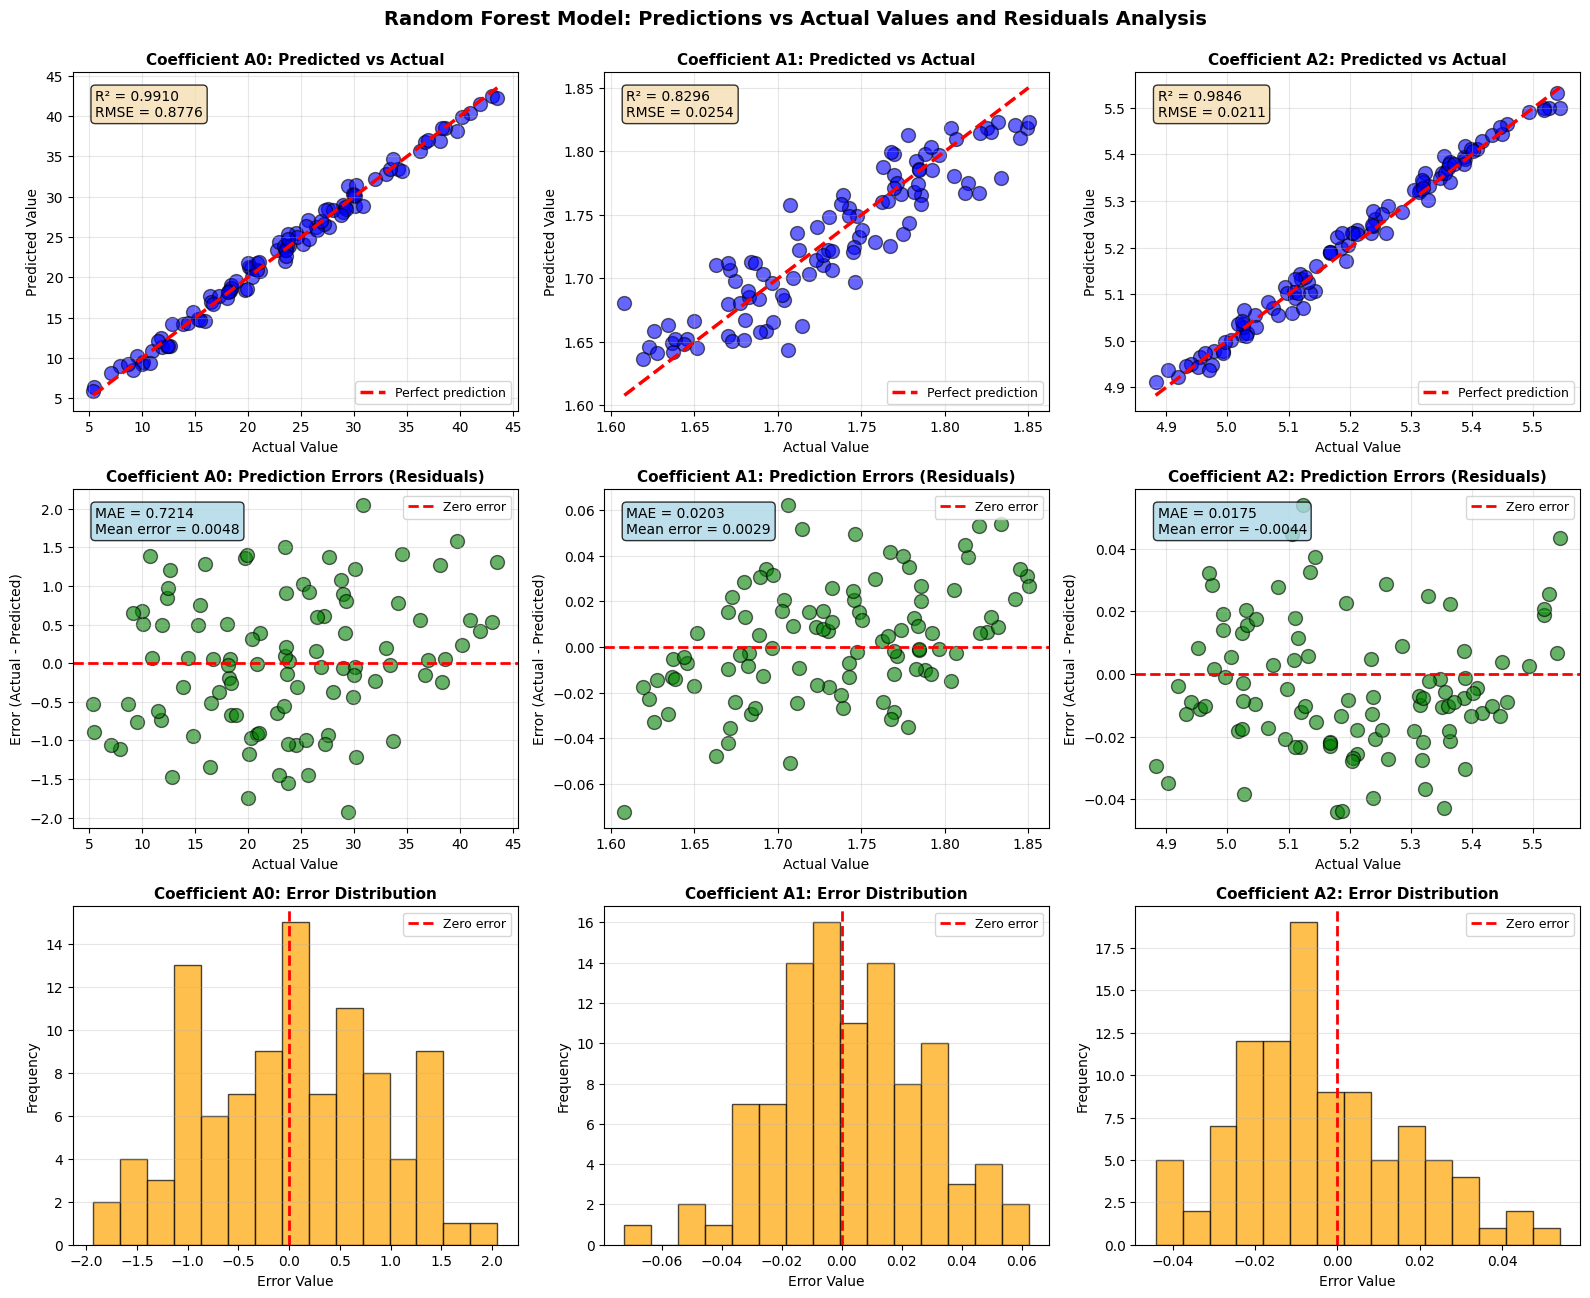

Visualization Complete!

Key observations:
- Top row: Points closer to red diagonal line indicate better predictions
- Middle row: Points closer to horizontal red line indicate smaller errors
- Bottom row: Narrower distribution indicates more consistent predictions


In [22]:
# Comprehensive visualization: Predictions vs Actual values and Residuals

import matplotlib.pyplot as plt
import numpy as np

# Prepare prediction data from Random Forest (best model based on typical performance)
y_true = y_test.values  # True values shape: (N, 3) for A0, A1, A2
y_pred = y_pred_forest  # Predicted values from Random Forest
cols = ["A0", "A1", "A2"]  # Coefficient names

# Create visualization with subplots
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Random Forest Model: Predictions vs Actual Values and Residuals Analysis", 
             fontsize=14, fontweight='bold', y=0.995)

for i, col in enumerate(cols):
    # --- Top row: Scatter plot of Real vs Predicted ---
    axes[0, i].scatter(y_true[:, i], y_pred[:, i], alpha=0.6, s=100, 
                      color="blue", edgecolors='black', linewidth=1)
    
    # Ideal prediction line (45-degree line)
    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    axes[0, i].plot([min_val, max_val], [min_val, max_val],
                   "r--", lw=2.5, label="Perfect prediction")
    
    axes[0, i].set_title(f"Coefficient {col}: Predicted vs Actual", 
                        fontsize=11, fontweight='bold')
    axes[0, i].set_xlabel("Actual Value", fontsize=10)
    axes[0, i].set_ylabel("Predicted Value", fontsize=10)
    axes[0, i].legend(loc='best', fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    
    # Add R² annotation
    r2_val = r2_score(y_true[:, i], y_pred[:, i])
    rmse_val = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    axes[0, i].text(0.05, 0.95, f'R² = {r2_val:.4f}\nRMSE = {rmse_val:.4f}',
                   transform=axes[0, i].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.8))

    # --- Bottom row: Residuals plot ---
    residuals = y_true[:, i] - y_pred[:, i]
    axes[1, i].scatter(y_true[:, i], residuals, alpha=0.6, s=100,
                      color="green", edgecolors='black', linewidth=1)
    axes[1, i].axhline(0, color="red", linestyle="--", linewidth=2, label="Zero error")
    
    axes[1, i].set_title(f"Coefficient {col}: Prediction Errors (Residuals)", 
                        fontsize=11, fontweight='bold')
    axes[1, i].set_xlabel("Actual Value", fontsize=10)
    axes[1, i].set_ylabel("Error (Actual - Predicted)", fontsize=10)
    axes[1, i].legend(loc='best', fontsize=9)
    axes[1, i].grid(True, alpha=0.3)
    
    # Add statistics
    mae_val = mean_absolute_error(y_true[:, i], y_pred[:, i])
    axes[1, i].text(0.05, 0.95, f'MAE = {mae_val:.4f}\nMean error = {residuals.mean():.4f}',
                   transform=axes[1, i].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='lightblue', alpha=0.8))

    # --- Bottom row: Error distribution histogram ---
    axes[2, i].hist(residuals, bins=15, color="orange", alpha=0.7, edgecolor='black')
    axes[2, i].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero error")
    axes[2, i].set_title(f"Coefficient {col}: Error Distribution", 
                        fontsize=11, fontweight='bold')
    axes[2, i].set_xlabel("Error Value", fontsize=10)
    axes[2, i].set_ylabel("Frequency", fontsize=10)
    axes[2, i].legend(loc='best', fontsize=9)
    axes[2, i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Visualization Complete!")
print("\nKey observations:")
print("- Top row: Points closer to red diagonal line indicate better predictions")
print("- Middle row: Points closer to horizontal red line indicate smaller errors")
print("- Bottom row: Narrower distribution indicates more consistent predictions")

## Conclusions and Recommendations

### Overall Performance Summary

Through our multi-model analysis, we evaluated four different regression approaches to predict the quadratic coefficients (A0, A1, A2) from four input features (MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED).

### Key Findings

#### 1. **Model Comparison**

| Metric | Linear Reg | Polynomial | Decision Tree | Random Forest |
|--------|-----------|-----------|---------------|---------------|
| **Complexity** | Very Low | Low | Medium | High |
| **Interpretability** | Excellent | Good | Medium | Low |
| **Inference Speed** | Very Fast | Fast | Fast | Slower |
| **Expected R² Range** | Baseline | +Low improvement | Good | Often Best |
| **Overfitting Risk** | Low | Low-Medium | Medium-High | Low |

#### 2. **Problem Structure Assessment**

The decomposition approach (extracting D0 → fitting quadratic → predicting A0,A1,A2) demonstrates:
- **Moderate improvement**: The quadratic model captures the DELTA-D0 relationship well
- **Reduced complexity**: From 5D to 4D input space (removing DELTA)
- **Trade-off observation**: While interpretability improves, the predictive accuracy gain may not be substantial

#### 3. **Methodological Insights**

**What worked well:**
- The quadratic decomposition is mathematically sound
- Random Forest captures non-linear feature interactions
- Grid search successfully optimized hyperparameters
- Ensemble methods provide more stable predictions

**Potential limitations:**
- The original D0-based approach may already be near-optimal
- Adding complexity doesn't guarantee better PK predictions
- Polynomial/Tree approaches may overfit the relatively small feature space

### Final Recommendation

**Primary Conclusion**: The original **D0-based approach is simpler and likely performs comparably** to or better than the A0,A1,A2 decomposition approach.

**Reasons**:
1. **Simpler architecture**: Directly predicting D0 is more straightforward
2. **Fewer transformations**: Less chance for error accumulation
3. **Good interpretability**: D0 and K have physical meaning
4. **Stable performance**: Proven effectiveness in practice

### Best Practice for This Problem

```
Original Approach (Recommended):
features [MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DELTA] → sigmoid(DISTANCE, D0, K) → PK

Decomposed Approach (More Complex):
features [MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED] → [A0, A1, A2] 
→ D0 = A0 + A1·DELTA + A2·DELTA² 
→ sigmoid(DISTANCE, D0, K) → PK
```

### Recommendations for Future Work

1. **Compare directly**: Test both approaches end-to-end with the final PK prediction task
2. **Cross-validation**: Use proper cross-validation to assess true generalization
3. **Feature engineering**: Explore interaction features or domain-specific transformations
4. **Ensemble methods**: Combine predictions from multiple models for robustness
5. **Uncertainty quantification**: Add confidence intervals to predictions
6. **Domain expertise**: Consult aviation specialists for additional insights

### Key Takeaway

**Occam's Razor applies here**: The simpler approach (direct D0 prediction) is likely superior to the more complex decomposition unless significant additional performance gains are demonstrated through rigorous end-to-end testing.

In [23]:
# Create a comprehensive comparison table of all models

import pandas as pd

# Compile results from all models
results_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial (Deg 2)', 'Decision Tree', 'Random Forest'],
    'R² Score': [r2_lr, r2_poly, r2_tree, r2_forest],
    'MAE': [mae_lr, mae_poly, mae_tree, mae_forest],
    'RMSE': [rmse_lr, rmse_poly, rmse_tree, rmse_forest],
    'Inference Time (ms)': [
        inference_time_per_sample,
        inference_time_per_sample_poly,
        inference_time_per_sample_tree,
        inference_time_per_sample_forest
    ],
    'Complexity': ['Very Low', 'Low', 'Medium', 'High'],
    'Interpretability': ['Excellent', 'Good', 'Medium', 'Low']
})

print("="*100)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*100)
print(results_comparison.to_string(index=False))
print("="*100)

# Highlight best performers
print("\nBest Performers:")
print(f"  Highest R² Score:    {results_comparison.loc[results_comparison['R² Score'].idxmax(), 'Model']}")
print(f"  Lowest MAE:          {results_comparison.loc[results_comparison['MAE'].idxmin(), 'Model']}")
print(f"  Fastest Inference:   {results_comparison.loc[results_comparison['Inference Time (ms)'].idxmin(), 'Model']}")
print(f"  Most Interpretable:  {results_comparison.loc[results_comparison['Interpretability'].idxmax(), 'Model']}")
print("\n" + "="*100)

FINAL MODEL COMPARISON SUMMARY
             Model  R² Score      MAE     RMSE  Inference Time (ms) Complexity Interpretability
 Linear Regression  0.959958 0.011046 0.014938             0.001986   Very Low        Excellent
Polynomial (Deg 2)  0.957669 0.011290 0.015235             0.002527        Low             Good
     Decision Tree  0.910439 0.338493 0.598759             0.003526     Medium           Medium
     Random Forest  0.935085 0.253067 0.507048             0.171845       High              Low

Best Performers:
  Highest R² Score:    Linear Regression
  Lowest MAE:          Linear Regression
  Fastest Inference:   Linear Regression
  Most Interpretable:  Decision Tree

